# Data Exploration & Preprocessing Design
This notebook explores the State Farm distracted driver dataset located in `model/data/`.  
Goals:
- Understand dataset structure and class distribution  
- Visualise samples  
- Inspect image resolutions  
- Test augmentation strategies  
- Propose preprocessing pipeline for training  


In [20]:
import os
import glob
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import random

DATA_ROOT = "../data/"
IMG_ROOT = os.path.join(DATA_ROOT, "imgs")
TRAIN_IMG_ROOT = os.path.join(IMG_ROOT, "train")

## Verify dataset structure

In [7]:
classes = sorted(os.listdir(TRAIN_IMG_ROOT))
classes

['c0', 'c1', 'c2', 'c3', 'c4', 'c5', 'c6', 'c7', 'c8', 'c9']

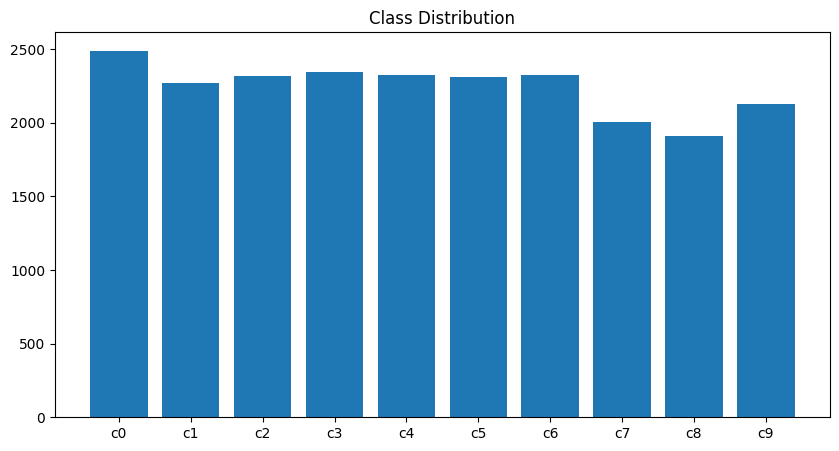

In [10]:
counts = {c: len(os.listdir(os.path.join(TRAIN_IMG_ROOT, c))) for c in classes}
pd.DataFrame.from_dict(counts, orient="index", columns=["count"])
plt.figure(figsize=(10,5))
plt.bar(counts.keys(), counts.values())
plt.title("Class Distribution")
plt.show()

## Class Map

In [11]:
class_map = {
    "c0": "safe driving",
    "c1": "texting - right",
    "c2": "talking on phone - right",
    "c3": "texting - left",
    "c4": "talking on phone - left",
    "c5": "operating the radio",
    "c6": "drinking",
    "c7": "reaching behind",
    "c8": "hair and makeup",
    "c9": "talking to passenger"
}
class_map

{'c0': 'safe driving',
 'c1': 'texting - right',
 'c2': 'talking on phone - right',
 'c3': 'texting - left',
 'c4': 'talking on phone - left',
 'c5': 'operating the radio',
 'c6': 'drinking',
 'c7': 'reaching behind',
 'c8': 'hair and makeup',
 'c9': 'talking to passenger'}

## Visualise Sample Images

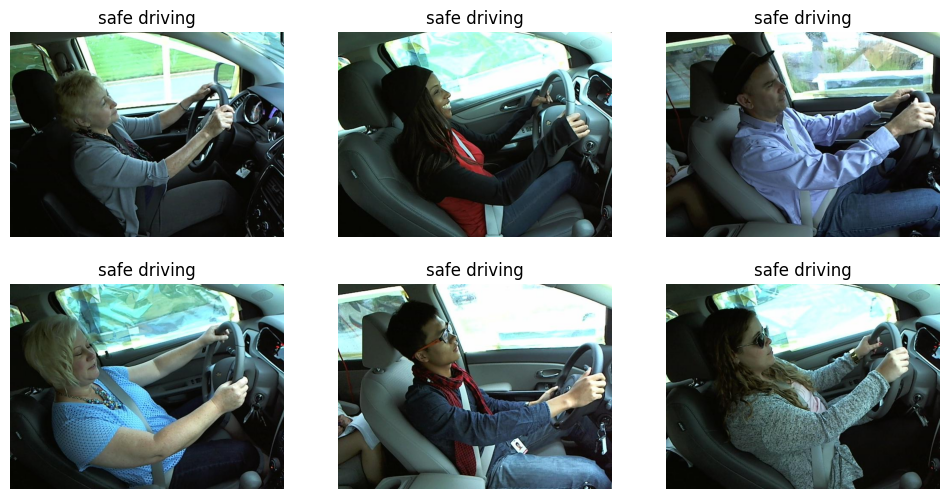

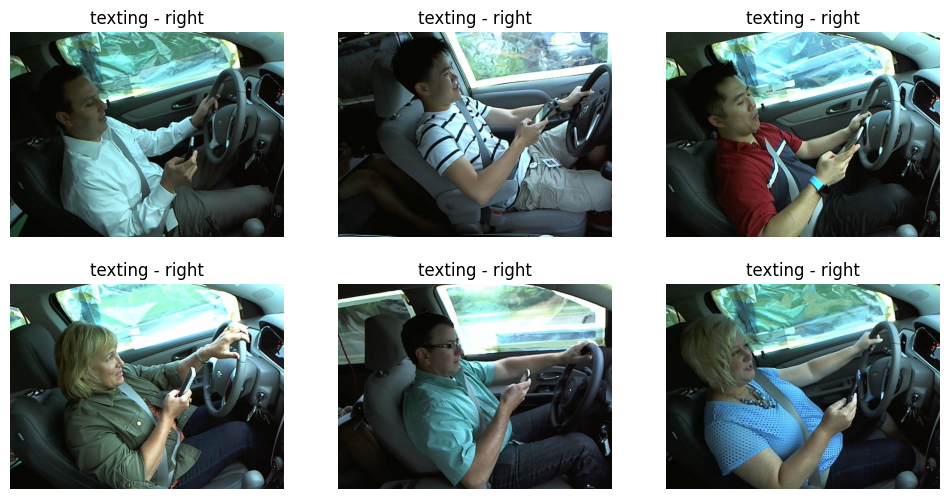

In [13]:
def show_samples(class_id, n=6):
    paths = glob.glob(os.path.join(TRAIN_IMG_ROOT, class_id, "*.jpg"))
    samples = random.sample(paths, n)
    
    plt.figure(figsize=(12,6))
    for i, p in enumerate(samples):
        img = Image.open(p)
        plt.subplot(2, n//2, i+1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(class_map[class_id])
    plt.show()

show_samples("c0")
show_samples("c1")


## Image Resolution Analysis
Confirm image sizes by sampling

In [17]:
sizes = []
for c in classes:
    paths = glob.glob(os.path.join(TRAIN_IMG_ROOT, c, "*.jpg"))
    for p in random.sample(paths, 50):  # sample for speed
        img = Image.open(p)
        sizes.append(img.size)

unique = set(sizes)
unique


{(640, 480)}

## Simple Augmentation Experiments

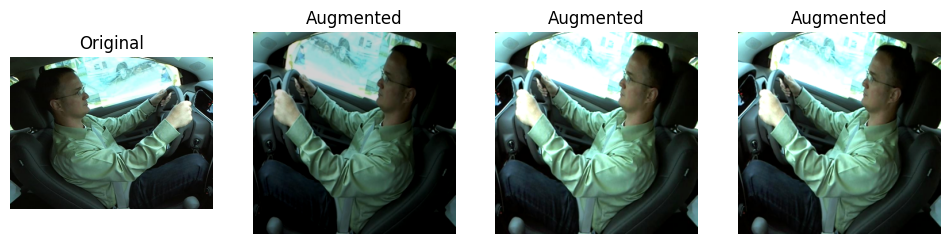

In [30]:
from torchvision import transforms

aug = transforms.Compose([
    transforms.Resize((256,256)),
    #transforms.RandomResizedCrop(224),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.RandomHorizontalFlip(),
])

def visualize_aug(class_id):
    path = random.choice(glob.glob(os.path.join(TRAIN_IMG_ROOT, class_id, "*.jpg")))
    img = Image.open(path)
    
    fig, axs = plt.subplots(1, 4, figsize=(12,4))
    axs[0].imshow(img)
    axs[0].set_title("Original")
    axs[0].axis("off")
    
    for i in range(1,4):
        aug_img = aug(img)
        axs[i].imshow(aug_img)
        axs[i].set_title("Augmented")
        axs[i].axis("off")

visualize_aug("c0")


RandomResizedCrop often removes parts of the image likely critical to classification. Resize, ColorJitter, and HorizontalFlip all maintain class meaning.